<a href="https://colab.research.google.com/github/GabrielColucciDev/Portifolio/blob/main/Projeto_Analise_A%C3%A7%C3%B5es_NVIDIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Uma Análise da NVIDIA (NVDA)

Olá! Meu nome é Gabriel Colucci muito obrigado por abrir meu projeto. 😄

Eu sempre gostei muito de PCs e Games então decidi fazer esse projeto utilizando a empresa que mais me persegue a NVIDIA. Explicarei passo a passo todas as tecnicas e pensamentos por traz de cada etapa de realização deste projeto.

**Obejetivo do projeto:**

Eu fiz esse projeto para demonstrar a aplicação de técnicas de ciência de dados e aprendizado de máquina para prever os preços futuros da ação da NVIDIA (NVDA). O objetivo é construir e avaliar um modelo de série temporal que possa aprender padrões históricos para fazer previsões realistas, servindo como uma prova de conceito de um sistema de previsão de mercado.

**Bibliotecas necessarias para o projeto: **📘

In [ ]:
# Instação da biblioteca yfinance
!pip install yfinance

#Bibliotecas necessarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ETAPA 1 : Buscando os dados ☁

Começando do começo primeiro eu fui atras de dados que fossem de fontes confiaveis e para isso eu utilizei a `yfinance`


In [ ]:
# Definir o ticker e o período de tempo
ticker = 'NVDA'
start_date = '2020-01-01'
end_date = '2025-01-01'

# Coletar os dados históricos de preços
dados_nvda = yf.download(ticker, start=start_date, end=end_date)

# Verificação inicial: Exibir as primeiras 5 linhas para garantir a coleta
print(dados_nvda.head())

/tmp/ipykernel_1338/2551693864.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_nvda = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.970754  5.970754  5.891364  5.941885  237536000
2020-01-03  5.875188  5.918990  5.826159  5.851047  205384000
2020-01-06  5.899826  5.905052  5.755728  5.781860  262636000
2020-01-07  5.971252  6.017045  5.883151  5.928197  314856000
2020-01-08  5.982451  6.023764  5.926952  5.967021  277108000


**A verificação inicial com ` dados_nvda.head()` confirmou que os dados foram baixados corretamente e que o DataFrame contém as colunas de preço (abertura, alta, baixa, fechamento) e volume, com o índice de datas devidamente formatado.**

# ETAPA 2: Análise Exploratória de Dados (EDA) 🔎

A EDA nos permite entender a natureza e as características dos dados antes de qualquer modelagem. Aqui, buscamos padrões, tendências e a qualidade geral da série temporal.

Criei a visualizaçã o de um `grafico temporal` que demonstra melhor o andamento desses dados ao longo do tempo.

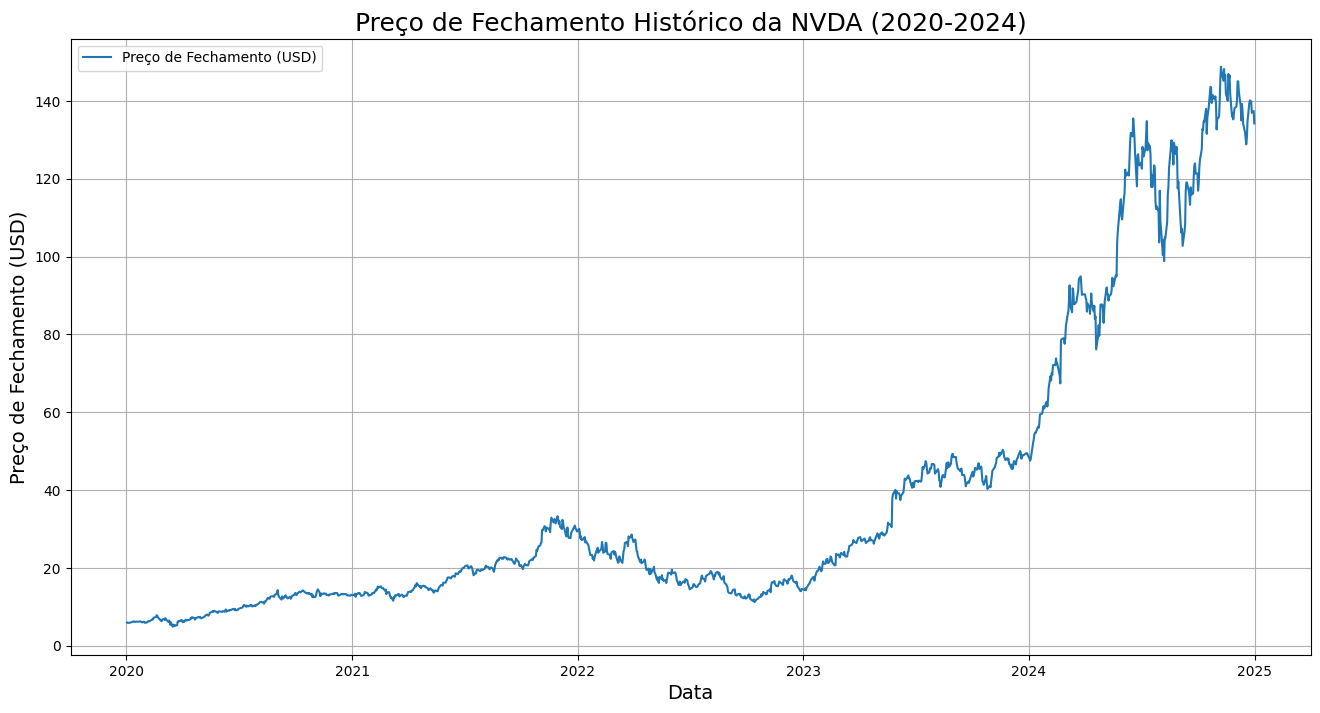

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(dados_nvda.index, dados_nvda['Close'], label='Preço de Fechamento (USD)')
plt.title('Preço de Fechamento Histórico da NVDA (2020-2024)', fontsize=18)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Preço de Fechamento (USD)', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

**O gráfico revela uma forte tendência de alta no preço das ações da NVDA, com uma volatilidade notável. Essa visualização é fundamental para confirmar o comportamento da série temporal que o modelo tentará prever.**

# Média e Mediana

O gráfico a seguir nos permite observar a evolução do preço de fechamento da NVDA e a posição de suas principais métricas de tendência central.





**Analise e implicações**

Análise e Implicações: O gráfico revela uma forte tendência de alta no preço das ações, o que indica que a série temporal é não-estacionária. Essa característica é crucial, pois exige que o modelo se adapte e aprenda com a tendência crescente. A **Média** *(linha tracejada vermelha)* é maior que a **Mediana** *(linha pontilhada verde)*, sugerindo que a distribuição de preços é assimétrica com uma cauda longa de valores mais altos. Isso reforça visualmente o forte crescimento do ativo.

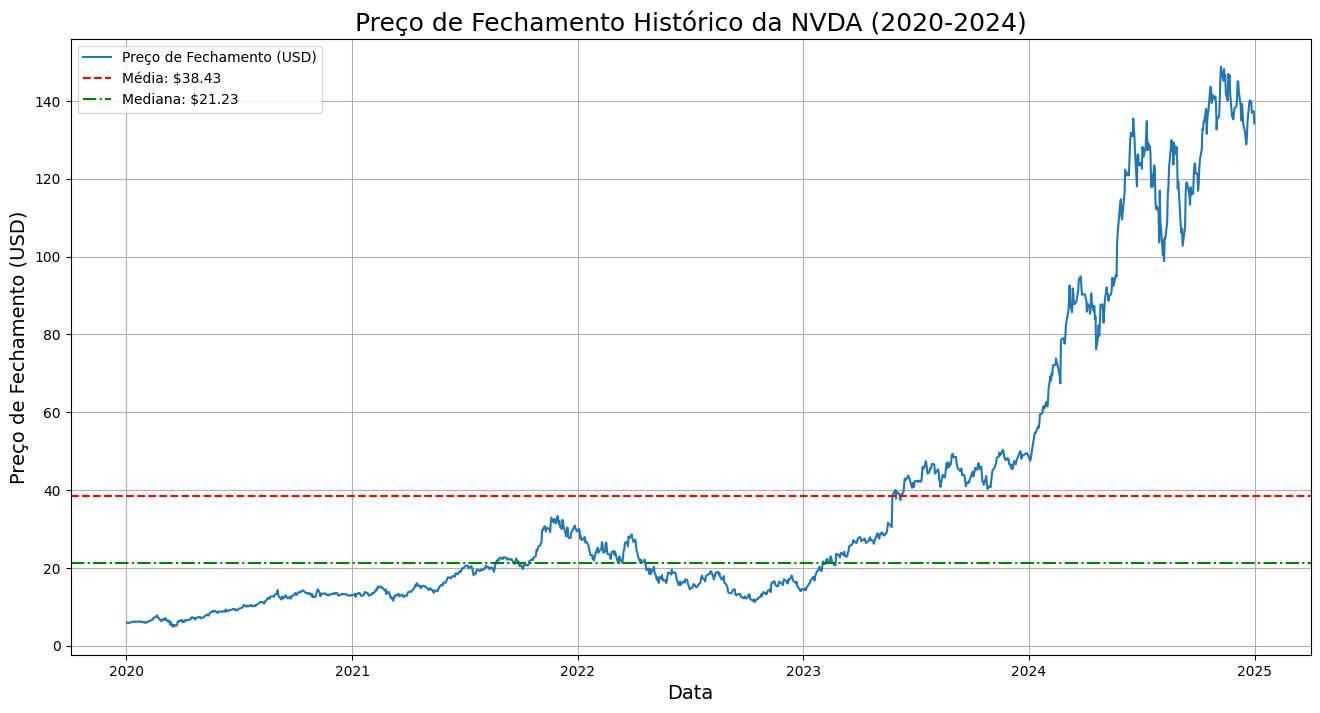

In [ ]:
# Calcular as métricas de média e mediana
media_preco = dados_nvda['Close'].mean()
mediana_preco = dados_nvda['Close'].median()

# Gerar o gráfico
plt.figure(figsize=(16, 8))
plt.plot(dados_nvda.index, dados_nvda['Close'], label='Preço de Fechamento (USD)')

# Adicionar linhas horizontais para a média e a mediana
plt.axhline(media_preco.iloc[0], color='r', linestyle='--', label=f'Média: ${media_preco.iloc[0]:.2f}')
plt.axhline(mediana_preco.iloc[0], color='g', linestyle='-.', label=f'Mediana: ${mediana_preco.iloc[0]:.2f}')

plt.title('Preço de Fechamento Histórico da NVDA (2020-2024)', fontsize=18)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Preço de Fechamento (USD)', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

# ETAPA 3: Análise Estatística 📈

A tabela de estatísticas descritivas nos dá um resumo quantitativo, com o desvio padrão *(std)* sendo uma métrica chave para entender a volatilidade da ação. A verificação de valores ausentes confirma a integridade do conjunto de dados, o que é crucial para garantir um treinamento de modelo consistente.



**Analise e implicações**

A tabela de estatísticas descritivas confirma o alto desvio padrão (std), uma métrica chave que quantifica a volatilidade do ativo. Para um modelo preditivo, a volatilidade é um desafio significativo, pois representa a imprevisibilidade do mercado. A verificação de valores ausentes confirma que o conjunto de dados está completo, um pré-requisito fundamental para um treinamento de modelo consistente e sem falhas.

In [ ]:
print("Estatísticas Descritivas dos Dados:")
# Usamos .describe() para obter métricas como média, desvio padrão, min e max
print(dados_nvda[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))
print("\n" + "="*50 + "\n")

# Calcular e exibir as métricas de moda, mediana e média individualmente
print(f"Média do preço de fechamento: ${dados_nvda['Close'].mean().iloc[0]:.2f}")
print(f"Mediana do preço de fechamento: ${dados_nvda['Close'].median().iloc[0]:.2f}")
print("Moda do preço de fechamento (valores mais frequentes):")
print(dados_nvda['Close'].mode())

print("\n" + "="*50 + "\n")

print("Verificação de Valores Ausentes:")

# Usamos .isnull().sum() para contar a quantidade de valores nulos em cada coluna
valores_ausentes = dados_nvda.isnull().sum()
if valores_ausentes.sum() == 0:
    print("Nenhum valor ausente encontrado. Os dados estão limpos e prontos para a modelagem.")
else:
    print(valores_ausentes)

Estatísticas Descritivas dos Dados:
Price      Open     High      Low    Close        Volume
Ticker     NVDA     NVDA     NVDA     NVDA          NVDA
count   1258.00  1258.00  1258.00  1258.00  1.258000e+03
mean      38.44    39.14    37.66    38.43  4.467728e+08
std       38.28    38.93    37.48    38.22  1.876933e+08
min        4.98     5.23     4.50     4.89  9.788400e+07
25%       13.60    13.82    13.33    13.57  3.084230e+08
50%       21.17    21.74    20.82    21.23  4.205830e+08
75%       45.74    46.19    44.96    45.61  5.467242e+08
max      149.29   152.83   146.20   148.82  1.543911e+09


Média do preço de fechamento: $38.43
Mediana do preço de fechamento: $21.23
Moda do preço de fechamento (valores mais frequentes):
Ticker        NVDA
0        13.158745
1        13.243632
2        22.195086
3        30.325890
4        49.491753
5       123.480469


Verificação de Valores Ausentes:
Nenhum valor ausente encontrado. Os dados estão limpos e prontos para a modelagem.


# ETAPA 4 - Identificação e Análise de Outliers ⭐

Nesta etapa indentifiquei os outliers para demonstrar melhor dados que se desviam significativamente do restante.

 Assim podemos tentar indentificar eventos inesperados (como notícias ou relatórios financeiros) que podem impactar o desempenho do modelo.

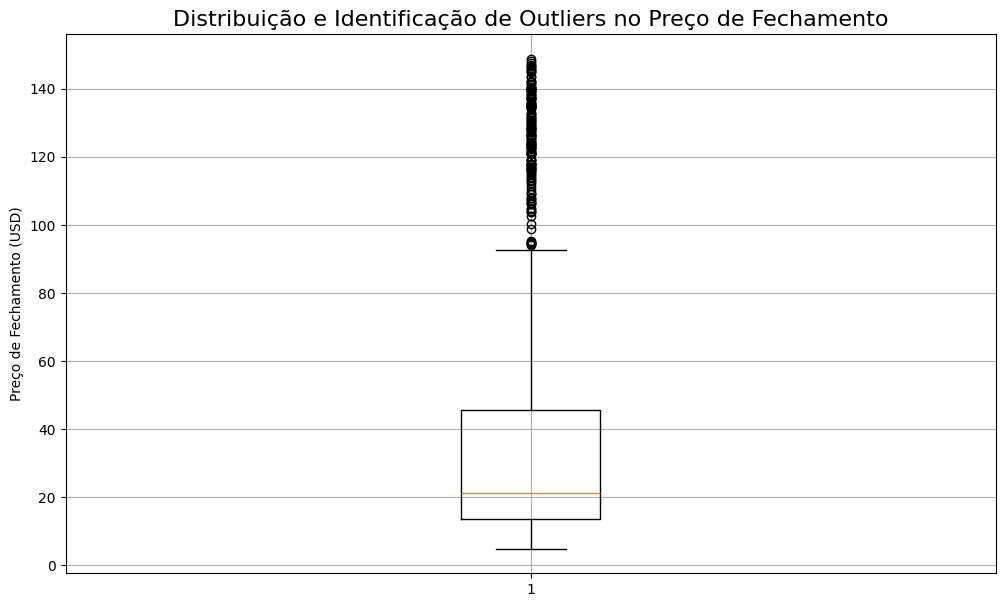


Foram encontrados 1258 outliers no preço de fechamento.

Os outliers (preços atípicos) são:
Price            Close
Ticker            NVDA
Date                  
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
...                ...
2024-12-24  140.174088
2024-12-26  139.884171
2024-12-27  136.965103
2024-12-30  137.444946
2024-12-31  134.246017

[1258 rows x 1 columns]


In [ ]:
# 1. Visualização com Gráfico de Caixa (Boxplot)
plt.figure(figsize=(12, 7))
plt.boxplot(dados_nvda['Close'])
plt.title('Distribuição e Identificação de Outliers no Preço de Fechamento', fontsize=16)
plt.ylabel('Preço de Fechamento (USD)')
plt.grid(True)
plt.show()

# 2. Identificação Estatística de Outliers usando o método IQR
Q1 = dados_nvda['Close'].quantile(0.25)
Q3 = dados_nvda['Close'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_detectados = dados_nvda[(dados_nvda['Close'] < limite_inferior) | (dados_nvda['Close'] > limite_superior)]

print(f"\nForam encontrados {len(outliers_detectados)} outliers no preço de fechamento.\n")
print("Os outliers (preços atípicos) são:")
print(outliers_detectados[['Close']])

# ETAPA 5 - Modelagem e treinamento

A Ideia aqui é preparar os dados para treinar um modelo de LSTM (long short-term memory)

A escolha deste modelo se da pela dinamica das ações em si que são afetadas por

*  Eventos que ocorreram a semanas ou meses atrás. A arquitetura de LSTM possui "Gates" (input, forget, output) que permitem que ela aprenda quais informações passadas reter e quais descartar. isso a torna superior a modelos lineares que sofrem com o problema de "gradiente que desaparece" e esquecem dependencias de longo prazo.Item da lista



*  Série Não-Estacionária: Nossos dados mostraram uma forte tendência de alta (não-estacionariedade). A LSTM lida muito bem com essa complexidade, aprendendo a tendência e a sazonalidade simultaneamente.





In [ ]:
# A. Normalização dos Dados
dados_fechamento = dados_nvda['Close'].values.reshape(-1, 1)
# Criar o objeto scaler (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
dados_normalizados = scaler.fit_transform(dados_fechamento)

# B. Divisão em Conjuntos de Treino e Teste (Divisão Temporal)
proporcao_treino = 0.80
tamanho_treino = int(len(dados_normalizados) * proporcao_treino)
dados_treino = dados_normalizados[0:tamanho_treino, :]
dados_teste = dados_normalizados[tamanho_treino:len(dados_normalizados), :]

# C. Função para criar as sequências de dados (X e y)
def criar_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        # X é a janela de 60 dias anteriores
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        # y é o preço do dia seguinte (o que queremos prever)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Definir o tamanho da "janela" de tempo
look_back = 60

# Criar os datasets de treino e teste
X_treino, y_treino = criar_dataset(dados_treino, look_back)
X_teste, y_teste = criar_dataset(dados_teste, look_back)

# D. Reformatar os dados para o modelo LSTM
# Formato exigido: [amostras, janelas de tempo, features]
X_treino = np.reshape(X_treino, (X_treino.shape[0], X_treino.shape[1], 1))
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1))

print("Pré-processamento Concluído. Formato dos dados:")
print("Formato de X_treino (entrada do modelo):", X_treino.shape)
print("Formato de y_treino (label a prever):", y_treino.shape)

Pré-processamento Concluído. Formato dos dados:
Formato de X_treino (entrada do modelo): (946, 60, 1)
Formato de y_treino (label a prever): (946,)


In [ ]:
# ETAPA 5.2 - Construção e Treinamento do Modelo LSTM

# Build the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

modelo = Sequential()

# LSTM Layer 1:
# units=50: Number of neurons in the layer. It's a common starting point.
# return_sequences=True: Indicates that the output of each time step should be passed to the next LSTM layer.
# input_shape: Defines the input shape [time windows (60), features (1)]
modelo.add(LSTM(units=50, return_sequences=True, input_shape=(X_treino.shape[1], 1)))

# LSTM Layer 2:
# units=50: Another layer to increase the complexity and learning capacity of the model.
# return_sequences=False: The last LSTM layer should return only the final value to the Dense layer.
modelo.add(LSTM(units=50, return_sequences=False))

# Output Layer (Dense):
# units=1: This is the final layer. Since we are predicting a single value (the next day's price), we use 1 unit.
modelo.add(Dense(units=1))

# Compile the model
# Optimizer ('adam'): Efficient and standard algorithm for optimizing the network.
# Loss ('mean_squared_error'): Ideal loss function for regression problems (predicting a continuous numerical value).
modelo.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model architecture
print("Resumo da Arquitetura do Modelo:")
modelo.summary()

# Train the model
# epochs=100: Number of times the model will see the entire training dataset.
# batch_size=32: Number of training samples processed before updating the model's internal weights.
print("\nIniciando o Treinamento...")
historico = modelo.fit(X_treino, y_treino, batch_size=32, epochs=100)
print("\nTreinamento Concluído.")

Resumo da Arquitetura do Modelo:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando o Treinamento...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.0030
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - loss: 2.5459e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 1.5893e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 1.4434e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 1.5123e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 1.3675e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 1.4402e-04
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.3021e-04
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1.2447e-04
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 1.2881e-04
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 1.1686e-04
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 1.0972e-04
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 1.2410e-04
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51m

In [ ]:
# ETAPA 6 - Avaliação do Modelo

# Fazer previsões no conjunto de teste
previsoes_teste_normalizadas = modelo.predict(X_teste)

# Inverter a normalização para obter as previsões na escala original de preço
previsoes_teste = scaler.inverse_transform(previsoes_teste_normalizadas)

# Inverter a normalização dos valores reais do teste
valores_reais_teste = scaler.inverse_transform(y_teste.reshape(-1, 1))

# Calcular o Root Mean Squared Error (RMSE)
rmse = sqrt(mean_squared_error(valores_reais_teste, previsoes_teste))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Calcular o Mean Absolute Error (MAE)
mae = mean_absolute_error(valores_reais_teste, previsoes_teste)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Opcional: Calcular outras métricas ou analisar visualmente os resultados
# Por exemplo, você pode plotar os valores reais vs. previstos.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Root Mean Squared Error (RMSE): 8.01
Mean Absolute Error (MAE): 6.65
